In [49]:
import os
import pydeseq2
import polars as pl
import pandas as pd
import numpy as np
import pickle

from matplotlib import pyplot as plt

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.default_inference import DefaultInference

In [2]:
base_dir = "/Users/jonah/"
comb_meta_p = os.path.join(base_dir, "cse283_AD_prediction/combined_metadata.tsv")
comb_meta =pd.read_csv(comb_meta_p, sep="\t")


In [3]:
comb_meta.index = comb_meta["sample_id"]

In [4]:
## Read Burgos df
counts_p = os.path.join(base_dir, "cse283_AD_prediction/burgos_dbgap/burgos_dbgap_counts.txt")
counts_df = pd.read_csv(counts_p, sep="\t")

col_is_serum = [col for col in counts_df.columns if col.endswith("_SER")]
serum_counts_df = counts_df[col_is_serum].T
burgos_meta_df_ordered = comb_meta.loc[serum_counts_df.index]

assert np.all(serum_counts_df.index == burgos_meta_df_ordered["sample_id"])


In [6]:
is_ad = burgos_meta_df_ordered["group"] == "AD"
is_control = ~is_ad

gene_means_ad = serum_counts_df.loc[is_ad].mean(axis=0).reset_index()
gene_means_ad.columns = ["gene", "mean_count"]

gene_means_control = serum_counts_df.loc[~is_ad].mean(axis=0).reset_index()
gene_means_control.columns = ["gene", "mean_count"]

In [ ]:
## Read Toden Data

In [7]:
toden_counts_p = os.path.join(base_dir, "cse283_AD_prediction/toden/toden_counts.txt")
toden_counts_df = pd.read_csv(toden_counts_p, sep="\t").T
toden_meta_ordered = comb_meta.loc[toden_counts_df.index]
assert np.all(toden_counts_df.index == toden_meta_ordered["sample_id"])


In [ ]:
## Read Silver-seq Data

In [8]:
silver_counts_p = os.path.join(base_dir, "cse283_AD_prediction/silver_seq/silver_seq_counts.txt")
silver_counts_df = pd.read_csv(silver_counts_p, sep="\t").T  # timepoints x genes


silver_sample_meta = comb_meta.loc[silver_counts_df.index]
assert np.all(silver_sample_meta["sample_id"] == silver_counts_df.index)

silver_counts_df = silver_counts_df.groupby(silver_sample_meta["subject_id"].values).sum()
silver_counts_df.index.name = "subject_id"

# One metadata row per subject (group is constant within a subject, verified upstream)
silver_meta_ordered = (
    silver_sample_meta.drop_duplicates("subject_id")
    .set_index("subject_id")
    .loc[silver_counts_df.index]
)

assert np.all(silver_meta_ordered.index == silver_counts_df.index)

In [ ]:
# Run DE

In [10]:
def run_deseq2_de(counts_df, metadata_df, tested_level, reference_level,
                  design_factor="group", alpha=0.05, n_cpus=2):
    metadata_df = metadata_df.copy()
    metadata_df[design_factor] = pd.Categorical(
        metadata_df[design_factor].astype(str),
        categories=[reference_level, tested_level],
    )
 
    inference = DefaultInference(n_cpus=n_cpus)
    dds = DeseqDataSet(
        counts=counts_df,
        metadata=metadata_df,
        design=f"~{design_factor}",
        refit_cooks=True,
        inference=inference,
    )
    dds.deseq2()
 
    stat_res = DeseqStats(
        dds,
        contrast=[design_factor, tested_level, reference_level],
        alpha=alpha,
        inference=inference,
    )
    stat_res.summary()
    stat_res.lfc_shrink(coeff=f"{design_factor}[T.{tested_level}]")
 
    results = stat_res.results_df.copy()
    results["significant"] = results["padj"] < alpha
    results = results.sort_values("padj", na_position="last")
    return results, dds, stat_res
 

In [11]:
results_burgos, dds_burgos, stat_res_burgos = run_deseq2_de(
    counts_df=serum_counts_df,
    metadata_df=burgos_meta_df_ordered,
    design_factor="group",
    tested_level="AD",
    reference_level="control",
    n_cpus=2,
)

results_toden, dds_toden, stat_res_toden = run_deseq2_de(
    counts_df=toden_counts_df,
    metadata_df=toden_meta_ordered,
    design_factor="group",
    tested_level="AD",
    reference_level="control",
    n_cpus=2,
)


Fitting size factors...
... done in 0.09 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 8.14 seconds.

Fitting dispersion trend curve...
/Users/jonah/miniforge3/envs/pydeseq2_env/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.39 seconds.

Fitting MAP dispersions...
... done in 9.53 seconds.

Fitting LFCs...
... done in 21.84 seconds.

Calculating cook's distance...
... done in 0.29 seconds.

Replacing 11802 outlier genes.

Fitting dispersions...
... done in 2.97 seconds.

Fitting MAP dispersions...
... done in 3.31 seconds.

Fitting LFCs...
... done in 5.45 seconds.

Running Wald tests...
... done in 2.35 seconds.

Fitting MAP LFCs...


Log2 fold change & Wald test p-value: group AD vs control
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  padj
ENSG00000223972  0.000000             NaN       NaN       NaN       NaN   NaN
ENSG00000227232  0.000000             NaN       NaN       NaN       NaN   NaN
ENSG00000278267  0.000000             NaN       NaN       NaN       NaN   NaN
ENSG00000243485  0.000000             NaN       NaN       NaN       NaN   NaN
ENSG00000274890  0.000000             NaN       NaN       NaN       NaN   NaN
...                   ...             ...       ...       ...       ...   ...
ENSG00000275028  0.000000             NaN       NaN       NaN       NaN   NaN
ENSG00000278806  1.014065        0.310218  2.179963  0.142304  0.886840   NaN
ENSG00000274152  0.073313        1.013641  2.493172  0.406567  0.684326   NaN
ENSG00000276666  0.000163        0.861538  3.034681  0.283897  0.776489   NaN
ENSG00000277917  0.000000             NaN       NaN       NaN       NaN   NaN

[6067

/Users/jonah/miniforge3/envs/pydeseq2_env/lib/python3.11/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))
/Users/jonah/miniforge3/envs/pydeseq2_env/lib/python3.11/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))
... done in 23.39 seconds.



...

Fitting size factors...
... done in 0.29 seconds.

Fitting dispersions...
... done in 13.57 seconds.

Fitting dispersion trend curve...
... done in 0.57 seconds.

Fitting MAP dispersions...
... done in 12.69 seconds.

Fitting LFCs...
... done in 11.96 seconds.

Calculating cook's distance...
... done in 1.12 seconds.

Replacing 11240 outlier genes.

Fitting dispersions...
... done in 3.43 seconds.

Fitting MAP dispersions...
... done in 3.31 seconds.

Fitting LFCs...
... done in 3.37 seconds.

Running Wald tests...
... done in 2.46 seconds.



Log2 fold change & Wald test p-value: group AD vs control
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000223972  7.796802        0.535384  0.307125  1.743214  0.081296   
ENSG00000227232  6.578747       -0.093068  0.169558 -0.548885  0.583084   
ENSG00000278267  0.078770       -0.067372  1.296738 -0.051955  0.958565   
ENSG00000243485  0.000000             NaN       NaN       NaN       NaN   
ENSG00000274890  0.000000             NaN       NaN       NaN       NaN   
...                   ...             ...       ...       ...       ...   
ENSG00000275028  0.013634       -0.218433  2.913608 -0.074970  0.940239   
ENSG00000278806  0.000000             NaN       NaN       NaN       NaN   
ENSG00000274152  0.000000             NaN       NaN       NaN       NaN   
ENSG00000276666  0.000000             NaN       NaN       NaN       NaN   
ENSG00000277917  0.000000             NaN       NaN       NaN       NaN   

                     padj  
ENSG000002239

Fitting MAP LFCs...


Shrunk log2 fold change & Wald test p-value: group[T.AD]
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000223972  7.796802        0.410178  0.298520  1.743214  0.081296   
ENSG00000227232  6.578747       -0.082488  0.165814 -0.548885  0.583084   
ENSG00000278267  0.078770        0.018498  0.645653 -0.051955  0.958565   
ENSG00000243485  0.000000             NaN       NaN       NaN       NaN   
ENSG00000274890  0.000000             NaN       NaN       NaN       NaN   
...                   ...             ...       ...       ...       ...   
ENSG00000275028  0.013634       -0.017711  0.616111 -0.074970  0.940239   
ENSG00000278806  0.000000             NaN       NaN       NaN       NaN   
ENSG00000274152  0.000000             NaN       NaN       NaN       NaN   
ENSG00000276666  0.000000             NaN       NaN       NaN       NaN   
ENSG00000277917  0.000000             NaN       NaN       NaN       NaN   

                     padj  
ENSG0000022397

... done in 12.15 seconds.



In [12]:
results_silver, dds_silver, stat_res_silver = run_deseq2_de(
    counts_df=silver_counts_df,
    metadata_df=silver_meta_ordered,
    design_factor="group",
    tested_level="AD",
    reference_level="control",
    n_cpus=2,
)


Fitting size factors...
... done in 0.03 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 10.20 seconds.

Fitting dispersion trend curve...
... done in 0.71 seconds.

Fitting MAP dispersions...
... done in 10.35 seconds.

Fitting LFCs...
... done in 8.01 seconds.

Calculating cook's distance...
... done in 0.05 seconds.

Replacing 661 outlier genes.

Fitting dispersions...
... done in 0.15 seconds.

Fitting MAP dispersions...
... done in 0.13 seconds.

Fitting LFCs...
... done in 0.12 seconds.

Running Wald tests...
... done in 2.21 seconds.



Log2 fold change & Wald test p-value: group AD vs control
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000223972  0.432880        0.440517  2.197424  0.200470  0.841113   
ENSG00000227232  1.014103        0.110832  1.322632  0.083797  0.933218   
ENSG00000278267  0.431047        0.143263  2.014171  0.071127  0.943296   
ENSG00000243485  1.109166        1.641450  1.509039  1.087745  0.276708   
ENSG00000274890  0.000000             NaN       NaN       NaN       NaN   
...                   ...             ...       ...       ...       ...   
ENSG00000275028  2.048070        0.620529  1.159083  0.535362  0.592400   
ENSG00000278806  0.000000             NaN       NaN       NaN       NaN   
ENSG00000274152  0.117454        0.249427  3.237200  0.077050  0.938584   
ENSG00000276666  0.000000             NaN       NaN       NaN       NaN   
ENSG00000277917  0.000000             NaN       NaN       NaN       NaN   

                     padj  
ENSG000002239

Fitting MAP LFCs...
/Users/jonah/miniforge3/envs/pydeseq2_env/lib/python3.11/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))
/Users/jonah/miniforge3/envs/pydeseq2_env/lib/python3.11/site-packages/pydeseq2/utils.py:1088: RuntimeWarning: overflow encountered in exp
  counts - (counts + size) / (1 + size * np.exp(-xbeta - offset))


Shrunk log2 fold change & Wald test p-value: group[T.AD]
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000223972  0.432880    2.321406e-07  0.002017  0.200470  0.841113   
ENSG00000227232  1.014103    5.807436e-08  0.001732  0.083797  0.933218   
ENSG00000278267  0.431047    9.820381e-08  0.001745  0.071127  0.943296   
ENSG00000243485  1.109166    5.521604e-07  0.002347  1.087745  0.276708   
ENSG00000274890  0.000000             NaN       NaN       NaN       NaN   
...                   ...             ...       ...       ...       ...   
ENSG00000275028  2.048070    4.681159e-07  0.001892  0.535362  0.592400   
ENSG00000278806  0.000000             NaN       NaN       NaN       NaN   
ENSG00000274152  0.117454    1.000295e-07  0.002097  0.077050  0.938584   
ENSG00000276666  0.000000             NaN       NaN       NaN       NaN   
ENSG00000277917  0.000000             NaN       NaN       NaN       NaN   

                     padj  
ENSG0000022397

... done in 22.96 seconds.



In [ ]:
# Compare DE Results

In [13]:
results_burgos.columns = [f"{col}_burgos" for col in results_burgos.columns]
results_toden.columns = [f"{col}_toden" for col in results_toden.columns]
results_silver.columns = [f"{col}_silver" for col in results_silver.columns]


# results_burgos.columns = [f.replace("_burgos_", "_") for f in results_burgos.columns]
# results_toden.columns = [f.replace("_toden_", "_") for f in results_toden.columns]
# results_silver.columns = [f.replace("_silver_", "_") for f in results_silver.columns]




In [16]:
from upsetplot import from_indicators, plot

{'matrix': <Axes: >,
 'shading': <Axes: >,
 'totals': <Axes: >,
 'intersections': <Axes: ylabel='Intersection size'>}

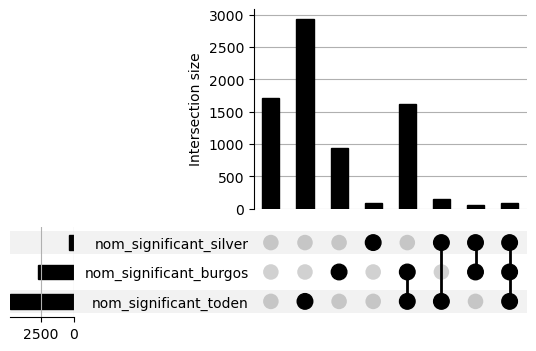

In [17]:
p_thresh = 0.05


results_silver["nom_significant_silver"] = results_silver["pvalue_silver"] < p_thresh
results_toden["nom_significant_toden"] = results_toden["pvalue_toden"] < p_thresh
results_burgos["nom_significant_burgos"] = results_burgos["pvalue_burgos"] < p_thresh

comb_results = pd.merge(results_burgos, results_toden, left_index=True, right_index=True, how="inner")
comb_results = pd.merge(comb_results, results_silver, left_index=True, right_index=True)
comb_results = comb_results.dropna()


upset_data = from_indicators(["nom_significant_burgos", "nom_significant_silver", "nom_significant_toden"], data=comb_results)

# Generate and show the plot
plot(upset_data)

In [18]:
# is_any_sig = comb_results["nom_significant_silver"] | comb_results["nom_significant_toden"] | comb_results["nom_significant_burgos"]
is_all_sig = comb_results["nom_significant_silver"] & comb_results["nom_significant_toden"] & comb_results["nom_significant_burgos"]
any_sig_comb_df = comb_results.loc[is_all_sig]

/var/folders/qz/r2wj364n18j6cln2k1dp44b00000gn/T/ipykernel_25187/3247407649.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/qz/r2wj364n18j6cln2k1dp44b00000gn/T/ipykernel_25187/3247407649.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/qz/r2wj364n18j6cln2k1dp44b00000gn/T/ipykernel_25187/3247407649.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


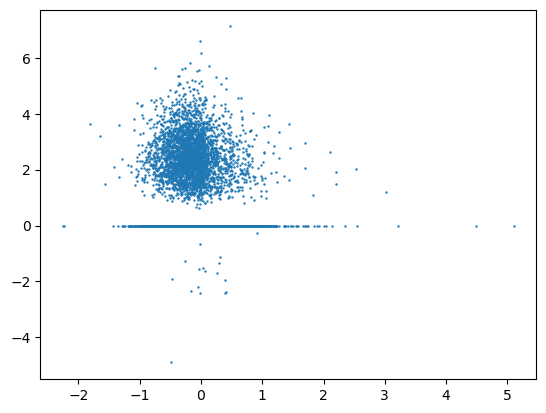

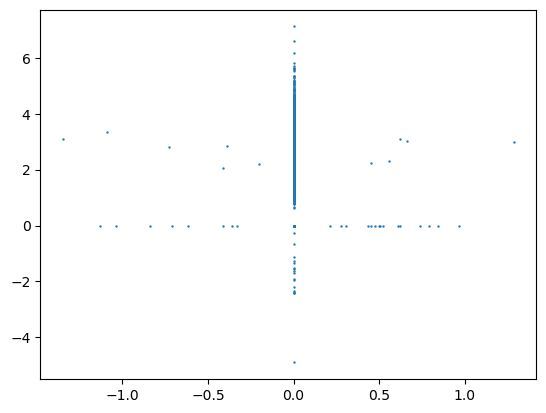

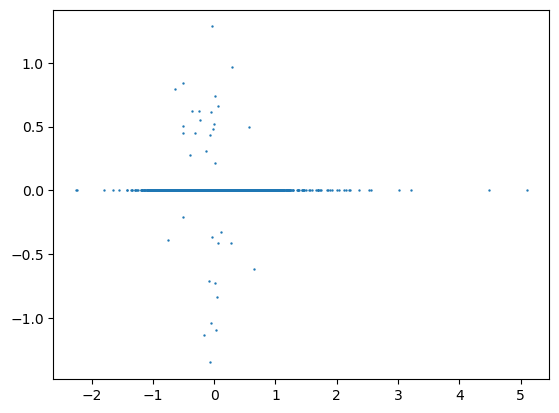

In [19]:
fig, ax = plt.subplots()
ax.scatter(comb_results["log2FoldChange_toden"], comb_results["log2FoldChange_burgos"], s=0.5)
fig.show()

fig, ax = plt.subplots()
ax.scatter(comb_results["log2FoldChange_silver"], comb_results["log2FoldChange_burgos"], s=0.5)
fig.show()

fig, ax = plt.subplots()
ax.scatter(comb_results["log2FoldChange_toden"], comb_results["log2FoldChange_silver"], s=0.5)
fig.show()

In [20]:
print(np.corrcoef(comb_results["stat_burgos"], comb_results["stat_toden"]))
print(np.corrcoef(comb_results["stat_silver"], comb_results["stat_toden"]))
print(np.corrcoef(comb_results["stat_silver"], comb_results["stat_burgos"]))

[[ 1.         -0.05478004]
 [-0.05478004  1.        ]]
[[1.         0.00472103]
 [0.00472103 1.        ]]
[[ 1.         -0.00627807]
 [-0.00627807  1.        ]]


In [53]:
burgos_genes = comb_results[comb_results["significant_burgos"]][["padj_burgos", "pvalue_burgos" ,"log2FoldChange_burgos"]]
toden_genes = comb_results[comb_results["significant_toden"]][["padj_toden", "pvalue_toden", "log2FoldChange_toden"]]
silver_genes = comb_results[comb_results["pvalue_silver"] < 0.01][["padj_silver", "pvalue_silver", "log2FoldChange_silver"]]


In [55]:
de_obj = {"burgos": burgos_genes, "toden": toden_genes, "silver": silver_genes}

In [56]:
de_obj

{'burgos':                   padj_burgos  pvalue_burgos  log2FoldChange_burgos
 ENSG00000201041  1.223651e-08   1.968867e-12           2.463523e+00
 ENSG00000096070  1.223651e-08   3.190746e-12           3.639085e+00
 ENSG00000208037  2.444639e-08   9.561820e-12           4.840546e-06
 ENSG00000166313  2.969375e-06   1.548566e-09           2.759515e+00
 ENSG00000205978  5.687437e-06   3.707586e-09           3.482782e+00
 ...                       ...            ...                    ...
 ENSG00000213160  4.980638e-02   1.078597e-02           2.390912e+00
 ENSG00000144366  4.998726e-02   1.083648e-02           2.168905e+00
 ENSG00000064601  4.998726e-02   1.083818e-02           1.230014e+00
 ENSG00000130592  4.998799e-02   1.084858e-02          -2.714308e-07
 ENSG00000231340  4.998799e-02   1.085137e-02           2.207578e-06
 
 [1648 rows x 3 columns],
 'toden':                    padj_toden  pvalue_toden  log2FoldChange_toden
 ENSG00000096070  1.734175e-03  2.426428e-04             -

In [57]:
pickle.dump(de_obj, open("./deseq_obj.pkl", "wb"))